# 시계열 분석

시계열은 같은 대상을 일정한 시간 간격으로 관측해서 시간 순서대로 늘어놓은 데이터를 의미한다.

월별 컨테이너 물동량, 하루 입항 척수, 시간별 동시 체류 척수 같은 데이터들이 시계열 데이터라고 볼 수 있다.

일반 데이터 같은 경우에는 행의 순서를 섞어도 분석 결과가 동일할 수 있으나, 시계열에서는 순서 자체가 정보이기 때문에 행을 섞는 순간에 지난달 보다 늘었다, 줄었다 하는 결론을 낼 수 없다.

시계열을 다룰때 가장 먼저 정해야 하는 사항이 있다.

- 시점: 각 값이 언제의 값
- 빈도: 값 사이의 간격이 얼마
- 변수: 한 시점에 무엇을 관측

## 날짜 인덱스

인덱스를 번호로 두는것이 아니라 데이터 내부의 시간을 인덱스로 설정하면 날짜 인덱스(Datetime Index)라고 일컫는다.

`pd.date_range()`

```python
df.loc[시작시간:끝시간]

df.loc['2024-02-01':'2024-12-31']
```

## 빈도, asfreq

시점 사이의 간격을 빈도(Frequency)라고 일컫는다. `index.freq`로 빈도를 확인할 수 있다.

`asfreq()`를 이용해서도 빈도를 구할 수 있는데, 중간에 빠진 달이 있으면 해당 월의 행을 새로 만들고 결측치(NaN)로 채운다.

## long, wide 형식

한 행에 날짜, 구분, 값을 하나씩 적어서 행이 길게 늘어지는 모양이, 날짜 하나를 한 행으로두고, 구분별 값을 옆으로 나란이 늘어 놓은 모양이 있다. 날짜, 구분, 값을 하나씩 적어서 행이 길게 늘어트린 모양을 long 형식이라고 일컫는다. 구분별 값을 옆으로 나란이 늘어 놓은 모양을 wide 형식.

시계열 분석에서는 날짜가 인덱스, 변수가 열인 wide형식이 계산시 유리하다.

long 모양을 wide 형식으로 변경할때에는 pivot(index=날짜열, columns=구분열, values=값에 해당되는 열)을 사용한다. 반대로 wide를 long 모양으로 변경할 때에는 melt()를 사용한다.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
long_df = pd.DataFrame({
    '연월': ['2024-01','2024-01','2024-02','2024-02'],
    '수출입구분설명': ['수출', '수입','수출', '수입'],
    '물동량': [458_000, 428_000, 422_000, 401_000, ]
})

print(long_df.shape)
long_df

(4, 3)


,연월,수출입구분설명,물동량
0,2024-01,수출,458000
1,2024-01,수입,428000
2,2024-02,수출,422000
3,2024-02,수입,401000


In [5]:
wide_df = long_df.pivot(index='연월', columns='수출입구분설명', values='물동량')

wide_df

수출입구분설명,수입,수출
연월,,
2024-01,428000,458000
2024-02,401000,422000


## 변화율

시계열데이터는 값 그 자체를 사용하기 보다는 변화율이라는 것을 사용한다. 3월 물동량 214만 TEU, 전년대비 3.2%증가 라는 문구에서는 후자가 변화에 대한 상황을 더 식별하기가 용이하다.

무엇과 비교하느냐에따라서 변화율의 뜻이 조금 달라진다. 비교 대상이 다른 두가지 증감률이랑 기간을 바꿔 합치는 리샘플링에 대해서 살펴보겠다.

- 전월 대비 증감율: 최근에 방향이 바뀌었는가 `pct_change()`
- 전년 동월대비 증감율: 계절을 빼고 봐도 늘었는가 `pct_change(12)`
- 연간 합계 증감율: 한해 실적이 늘었는가 `resample('YS').sum()` 한다음에 `pct_change()`

### 전월 대비 증감율

전월대비 증감율은 이번달 값을 바로 앖달과 비교한 '변화율'이다. 가장 최근의 방향 전환을 빨리 알아차릴수 있다는 장점이 있지만, 계절의 영향이 그대로 섞이는 단점도 있다.

- 전월대비증감율(%) = (이번달 값 - 전월달 값) / 지난달 값 * 100

### 전년 동월대비 증감률(Year over Year, YoY)

월별 물동량을 바로 앞달과 비교하면 계절의 영향이 포함될 수 있다. 연별로 같은 달끼리 비교하는 방법을 사용할 수도 있다. 올해 2월이랑 작년 2월을 비교하면 날짜 수랑 계절도 같기 때문에 계절 효과같은 내용들이 상당히 소거될 수 있다.

이렇게 전년도의 같은달처럼 같은 달끼리 비교하는 방식을 전년 동월대비 증감률이라고 일컫는다. `pct_change(12)`, `shift(12)`로 확인 가능하다.

전년 동월대비비교도 문제가 있을 수 있는데, 음력에따라 양력의 쉬는날(명절)이 변경될 수 있다. 작년에 설 2월이었는데 올해는 설이 1월이면, 같은 1월끼리 비교해도 연휴가 있어서 불리하고 유리하고가 바뀌게 된다. 1~2월값 합쳐서보면 어느정도는 해소 가능합니다.  처음 12개월은 비교할 작년이 없음.

- 전년동월대비증감률 = (올해 이번달 값 - 작년 같은달 값) / 작년 같은 달 값 * 100

## 리샘플링(Resampling)

월별 값을 연도별 합계로 바꾸거나 시간별 값을 일별 평균값으로 바꾸는 것은 시계열의 빈도를 바꾼것이다. 시계열의 빈도를 바꾸어서 다시 집계하는 것을 리샘플링이라고 일컫는다.

`groupby`는 같은 그룹끼리 묶는것이었다면, `resample`은 같은 기간끼리 묶는 것.

- `resample("YS")` : YS(Year Start)연초



# 시계열 구성요소

부산항 월별 물동량 그래프를 본다고 가정하면, 세가지 정도의 움직임을 포착할 수 있다.

장기간에 걸쳐서 꾸준하게 올라가는 흐름, 2월에 내려갔다가 3월에 올라가는 것과같은 반복되는 패턴, 어느 규칙으로도 설명이 어려운 들쭉날쭉한 변동이 있다.

- 추세(Trend): 오랜 기간에 걸친 방향
- 계절성(Seasonality): 정해진 주기로 반복되는 패턴
- 불규칙 변동(Residual, Irregular): 추세/계절성으로 설명되지 않는 나머지

## 자기상관(Autocorrelation)

계절성이 있는지를 눈으로만 판단하면 사람마다 결론이 다르다. 이때 사용하는 도구가 자기상관이다. 시계열을 일정 칸수만큼 밀어놓은 자기 자신과의 상관계수를 의미한다.

밀어놓은 칸수를 시차(Lag)라고 일컫고, 시차 12의 자기상관은 올해 각 달의 값과 작년 같은달의 값이 얼마나 비슷하게 움직이는가를 의미하고 -1, 1사이의 숫자로 표현한다.

`s.corr(s.shift(12)) `이렇게 구할 수 있고, `statsmodels`의 `acf()`로도 구할 수 있다.

추세가 강한 시계열은 모든 시차에서 자기상관이 1에 가깝게 나온다. 꾸준히 오르는 값은 한달 전, 여섯달 전에도 비슷하게 움직이기 때문이다. 그래서 계절주기를 찾을때에는 diff()로 전월과의 차이를 먼저 구해서 추세를 걷어낸 다음에 자기상관을 확인하는 것이 바람직하다.

- 시차k의 자기상관 = corr(값(t), 값(t-k))

In [6]:
def load_dataset(filename):
    BASE_DIR = './data'
    EXTENSION = '.csv'
    TARGET_PATH = f'{BASE_DIR}/{filename}{EXTENSION}'
    try:
        return pd.read_csv(TARGET_PATH)
    except FileNotFoundError:
        return None
    except UnicodeDecodeError:
        return pd.read_csv(TARGET_PATH, encoding='euc-kr')

In [7]:
TARGET = '물동량_예측'

df = load_dataset(TARGET)

In [8]:
df.shape

(1376, 6)

In [10]:
df.columns

Index(['연도', '월', '연월', '수출입구분', '수출입구분설명', '물동량'], dtype='str')

In [9]:
df['수출입구분'].value_counts()

수출입구분
OO    398
II    398
OT    290
IT    290
Name: count, dtype: int64

In [12]:
ts = df.pivot(
    index='연월',
    columns='수출입구분설명',
    values='물동량'
)
ts.index = pd.to_datetime(ts.index)
ts = ts.asfreq("MS")

ts = ts[['수출', '수입', '수출환적', '수입환적']]
ts

수출입구분설명,수출,수입,수출환적,수입환적
연월,,,,
1992-01-01,104567.00,92005.00,NaN,NaN
1992-02-01,103903.00,91669.00,NaN,NaN
1992-03-01,137082.00,105276.00,NaN,NaN
1992-04-01,130353.00,99261.00,NaN,NaN
1992-05-01,126586.00,95773.00,NaN,NaN
...,...,...,...,...
2024-10-01,469171.75,431582.50,573844.75,574791.75
2024-11-01,444568.50,421638.75,560592.25,571301.25
2024-12-01,442416.25,461852.75,569233.75,593917.50


In [15]:
print(ts.index.min(), ts.index.max(), len(ts))
print(ts.isna().sum())
print(ts['수출환적'].first_valid_index())

1992-01-01 00:00:00 2025-02-01 00:00:00 398
수출입구분설명
수출        0
수입        0
수출환적    108
수입환적    108
dtype: int64
2001-01-01 00:00:00


In [16]:
# sum(axis=1)은 기본적으로 NaN을 0처럼 건너뛰고 시작.
# 그래서 2000년 12월의 합계는 수출+수입 두개만 2001년 1월에는 수출+수입+수출환적+수입환적 네개 항목 다 더한값이 됨
# 물동량이 엄청나게 증가한것처럼 보인다.
ts.sum(axis=1)

연월
1992-01-01     196572.00
1992-02-01     195572.00
1992-03-01     242358.00
1992-04-01     229614.00
1992-05-01     222359.00
                 ...    
2024-10-01    2049390.75
2024-11-01    1998100.75
2024-12-01    2067420.25
2025-01-01    2126084.75
2025-02-01    1963543.50
Freq: MS, Length: 398, dtype: float64

In [19]:
ts['수입'].loc['2000-12':'2001-05']

연월
2000-12-01    360166.75
2001-01-01    195903.50
2001-02-01    185531.50
2001-03-01    227399.00
2001-04-01    222518.00
2001-05-01    224711.50
Freq: MS, Name: 수입, dtype: float64

In [20]:
total = ts.sum(axis=1, min_count=4)
total = total.loc['2001-01':]
total

연월
2001-01-01     629545.00
2001-02-01     578213.75
2001-03-01     716271.25
2001-04-01     681030.50
2001-05-01     668563.75
                 ...    
2024-10-01    2049390.75
2024-11-01    1998100.75
2024-12-01    2067420.25
2025-01-01    2126084.75
2025-02-01    1963543.50
Freq: MS, Length: 290, dtype: float64

In [23]:
plt.rcParams['font.family'] = 'Malgun Gothic'

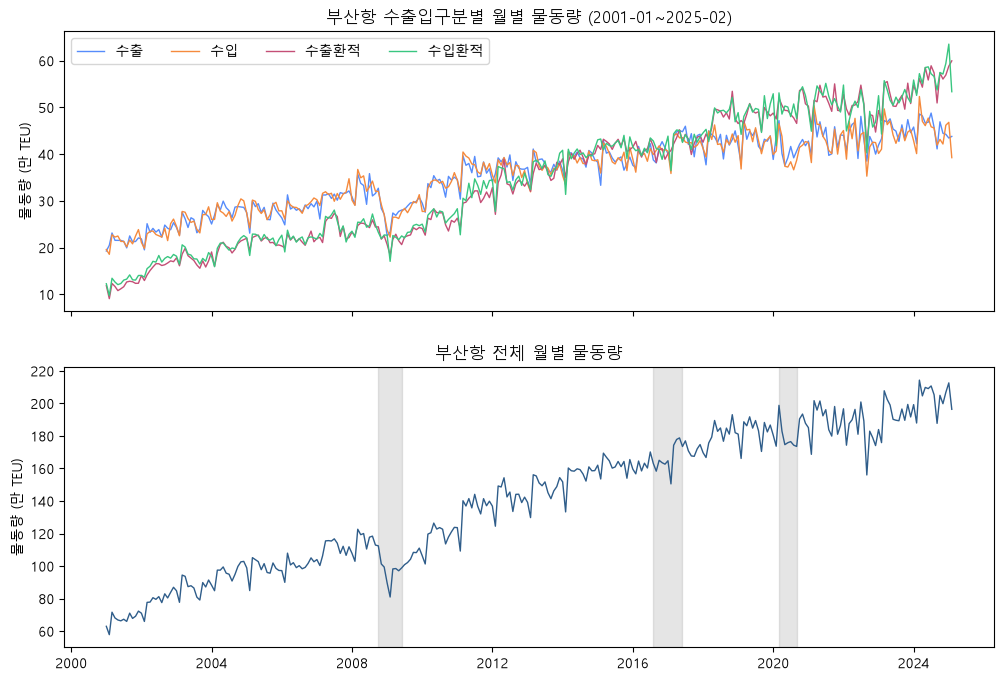

In [27]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

for col in ts.columns:
    axes[0].plot(ts.loc['2001':, col] / 10_000, label=col, linewidth=1)

axes[0].set_ylabel('물동량 (만 TEU)')
axes[0].set_title('부산항 수출입구분별 월별 물동량 (2001-01~2025-02)')
axes[0].legend(ncol=4)

axes[1].plot(total / 10_000, color='#2f5d8a', linewidth=1)

for start, end, label in [ ('2008-10', '2009-06', '금융위기'),
                           ('2016-08', '2017-06', '한진해운 파산'),
                           ('2020-03', '2020-9', '코로나')]:
    axes[1].axvspan(pd.Timestamp(start), pd.Timestamp(end), color='gray', alpha=0.2)

axes[1].set_ylabel('물동량 (만 TEU)')
axes[1].set_title('부산항 전체 월별 물동량')

plt.show()

In [29]:
growth = pd.DataFrame({
    '물동량':total,
    '전월대비':total.pct_change() * 100,
    '전년동월대비': total.pct_change(12) * 100,
})

growth.loc['2024-12':].round(2)

,물동량,전월대비,전년동월대비
연월,,,
2024-12-01,2067420.25,3.47,7.87
2025-01-01,2126084.75,2.84,6.71
2025-02-01,1963543.50,-7.65,4.48


In [30]:
months_per_year = total.resample('YS').count()
annual = total.resample('YS').sum()[months_per_year == 12]
annual_growth = annual.pct_change() * 100

In [33]:
a = 10
b = 1 if a >= 10 else -1

if a >= 10:
    b = 1
else:
    b = -1


C:\work\smartport\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


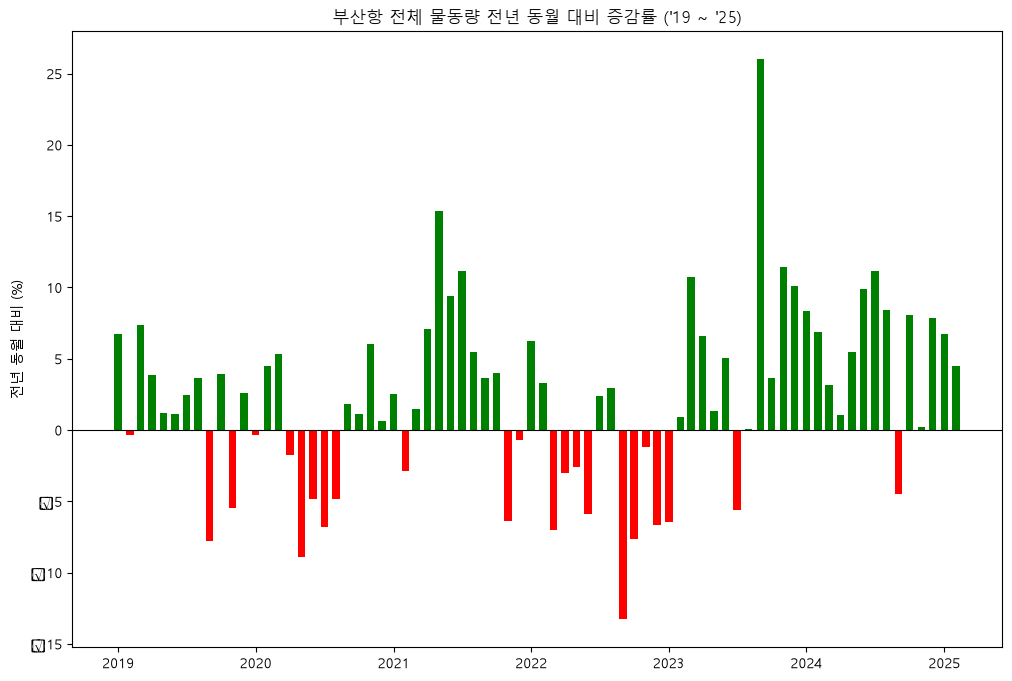

In [34]:
recent = growth.loc['2019':, '전년동월대비']

fig, ax = plt.subplots(figsize=(12, 8))

colors = [ 'green' if v >= 0 else 'red' for v in recent ]
ax.bar(recent.index, recent, width=20, color=colors)
ax.axhline(0, color='black', linewidth=0.8)

ax.set_ylabel('전년 동월 대비 (%)')
ax.set_title('부산항 전체 물동량 전년 동월 대비 증감률 (\'19 ~ \'25)')

plt.show()